[![render on GitHub](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/SecondGlanceFromAlice/Beer-hemian_Rhapsody/blob/main/examples/beerhemian_demo.ipynb)

[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/SecondGlanceFromAlice/Beer-hemian_Rhapsody.git/main?urlpath=lab/tree/examples/beerhemian_demo.ipynb)

[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SecondGlanceFromAlice/Beer-hemian_Rhapsody/blob/main/examples/beerhemian_demo.ipynb)

In [ ]:
# Uncomment for first run
!pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ Beer-hemian==0.2.3

In [11]:
import os
import matplotlib.pyplot as plt
import random
import numpy as np
from beerhemian import load_all, dominant_frequencies, plot_spectrum, plot_spectrum_multiple, plot_with_curve, sine_wave

In [3]:
SAMPLE_RATE = 44100
DURATION = 2

In [4]:
volume = [20, 30, 40, 50, 60]

random_density = random.randrange(900, 1000, 1) / 1000
random_uncertainty = random.randrange(20, 30, 1) / 1000

m = []

for v in range(0,5):
  m.append(volume[v] * random_density)

In [5]:
recordings = [
    ("BeerA-20.wav",  sine_wave(760, DURATION, SAMPLE_RATE), SAMPLE_RATE),
    ("BeerA-30.wav",  sine_wave(650, DURATION, SAMPLE_RATE), SAMPLE_RATE),
    ("BeerA-40.wav",  sine_wave(550, DURATION, SAMPLE_RATE), SAMPLE_RATE),
    ("BeerA-50.wav",  sine_wave(409, DURATION, SAMPLE_RATE), SAMPLE_RATE),
    ("BeerA-60.wav",  sine_wave(310, DURATION, SAMPLE_RATE), SAMPLE_RATE),
]

In [6]:
df, fft_data = dominant_frequencies(
    recordings,
    mass=m,
    mass_unc=[random_uncertainty] * len(m),
)

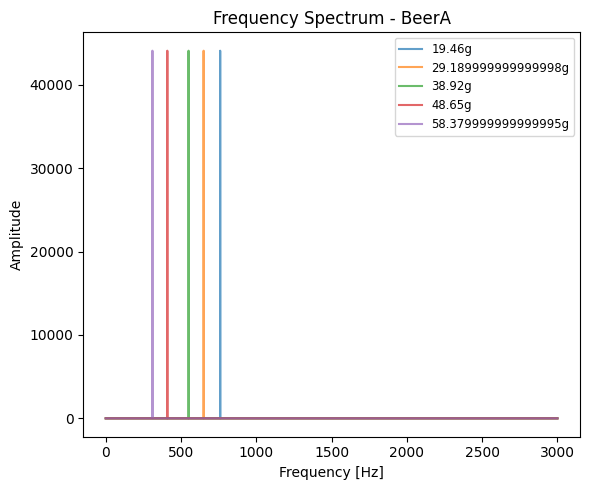

In [15]:
# This one is usefull for more than one sample

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

plot_spectrum_multiple(fft_data, df, ax=ax)

plt.tight_layout()
plt.show()

In [16]:
plot_spectrum_multiple(fft_data, df, ax, max_freq=1000)

This is the moment where I know that I should have used Pint. In one function there is [ml] and in the other one [g]

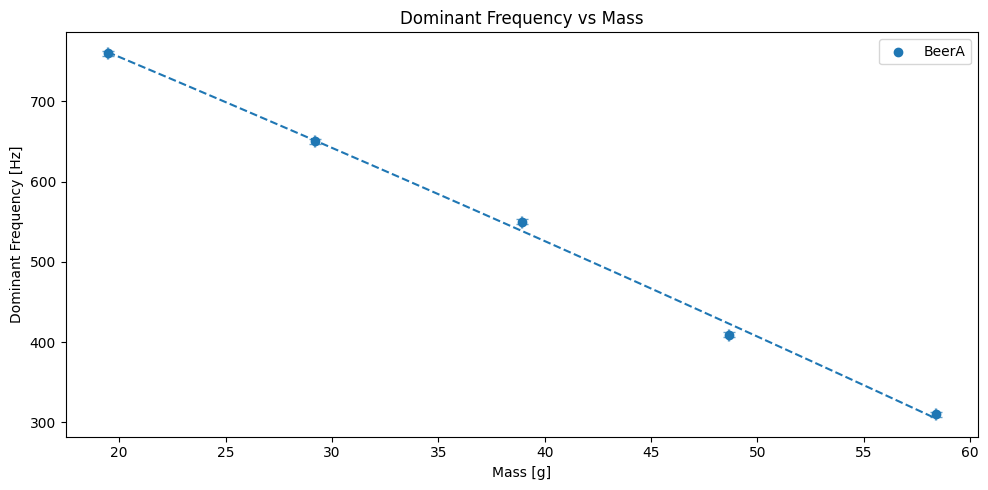

In [17]:
plt.figure(figsize=(10, 5))

for beer in df["Beer"].unique():
    beer_df = df[df["Beer"] == beer].sort_values("mass")
    plot_with_curve(beer, beer_df["mass"].values, beer_df["um"].values, beer_df["frequencies"].values)

plt.title("Dominant Frequency vs Mass")
plt.xlabel("Mass [g]")
plt.ylabel("Dominant Frequency [Hz]")
plt.legend()
plt.tight_layout()
plt.show()